# 📁 NB 1 – Daten vorbereiten
**YOLO11 | Windows lokal | Label Studio | Gemischtes Niveau**

| Abschnitt | Inhalt |
|-----------|--------|
| 0 | Virtuelle Umgebung mit `uv` |
| 1 | Konfiguration (Pfade, Klassen, Split) |
| 2 | Best Practices – Bilder aufnehmen |
| 3 | Annotieren mit Label Studio (Local Storage) |
| 4 | Dateien umbenennen |
| 5 | Train / Val / Test Split |
| 6 | data.yaml erstellen |
| 7 | Abschlussbericht & Strukturcheck |
| 8 | Annotationskontrolle (Bilder mit Bounding Boxes) |

> ⚠️ **Reihenfolge einhalten** – Zellen von oben nach unten ausführen.

---

---
## 🛠️ Abschnitt 0 – Virtuelle Umgebung mit `uv`

### Was ist `uv`?
`uv` ist ein **extrem schneller** Python-Paketmanager (Rust), entwickelt von Astral.
Kein separates `pip` oder `venv` nötig.

### Python-Version

| Paket | Empfohlen | Hinweis |
|-------|-----------|--------|
| `ultralytics` | **3.11** | PyTorch-Abhängigkeiten |
| `streamlit` | 3.11 | stabil |
| `jupyter` | 3.11 | stabil |

> ⚠️ **Python 3.13 vermeiden** – PyTorch noch nicht kompatibel.

### Einrichtung (CMD, einmalig)

```cmd
# 1. uv installieren
powershell -ExecutionPolicy ByPass -c "irm https://astral.sh/uv/install.ps1 | iex"

# 2. Projekt anlegen (Python 3.11 direkt beim Init)
cd C:\YOLO
uv init --python 3.11 yolo_projekt
cd yolo_projekt

# 3. Pakete installieren
uv add ultralytics jupyter streamlit ipykernel label-studio
```

### Kernel in VS Code
1. `.ipynb` öffnen
2. Oben rechts **"Select Kernel"** → **"Python Environments"** → **`.venv (Python 3.11)`**

> 💡 `ipykernel` muss installiert sein – manuelle Kernel-Registrierung entfällt in VS Code.

In [1]:
# ── Überprüfung: Sind alle Pakete korrekt installiert? ────────────────
import sys, importlib

pakete = {
    "ultralytics" : "ultralytics",
    "streamlit"   : "streamlit",
    "jupyter"     : "jupyter_core",
    "torch"       : "torch",
    "torchvision" : "torchvision",
    "ipykernel"   : "ipykernel",
    "label-studio" : "label_studio",
}

print(f"Python : {sys.version}")
print(f"Pfad   : {sys.executable}")
print("-" * 48)

alle_ok = True
for anzeige, modul in pakete.items():
    try:
        m = importlib.import_module(modul)
        v = getattr(m, "__version__", "–")
        print(f"  ✅  {anzeige:<15} {v}")
    except ImportError:
        print(f"  ❌  {anzeige:<15} nicht installiert")
        alle_ok = False

print("-" * 48)
if alle_ok:
    print("✅ Alle Pakete vorhanden – Umgebung ist bereit!")
else:
    print("⚠️  Fehlende Pakete installieren:")
    print("   uv pip install ultralytics jupyter streamlit ipykernel")

Python : 3.12.11 (main, Jun  4 2025, 17:41:36) [MSC v.1943 64 bit (AMD64)]
Pfad   : c:\Users\rolfs\Documents\projekte\YOLO\YOLO_Workshop\.venv\Scripts\python.exe
------------------------------------------------
  ✅  ultralytics     8.4.33
  ✅  streamlit       1.56.0
  ✅  jupyter         5.9.1
  ✅  torch           2.10.0+cpu
  ✅  torchvision     0.25.0+cpu
  ✅  ipykernel       7.2.0
  ✅  label-studio    1.23.0
------------------------------------------------
✅ Alle Pakete vorhanden – Umgebung ist bereit!


---
## ⚙️ Abschnitt 1 – Konfiguration

> 🔧 **Nur hier anpassen** – alle nachfolgenden Zellen greifen auf diese Variablen zu.
> Klassennamen werden automatisch aus `Dataset/classes.txt` gelesen.

**Ordnerstruktur:**
```
../
├── Dataset/             ← Label Studio Export (Eingabe)
│   ├── images/
│   ├── labels/
│   └── classes.txt      ← Klassennamen (direkt in Dataset/)
└── Data/                ← Ausgabe nach Split
    ├── images/train|val|test
    ├── labels/train|val|test
    └── data.yaml
```

In [2]:
import pathlib

# ╔═══════════════════════════════════════════════╗
# ║   KONFIGURATION – alle Werte hier anpassen             ║
# ╚═══════════════════════════════════════════════╝

BASE_DIR    = r"../"               # Basisordner (relativ zum Notebook)

# Train / Val / Test Split (muss zusammen genau 1.0 ergeben)
# Tipp: SPLIT_TEST = 0.0 → kein Testset
SPLIT_TRAIN = 0.70
SPLIT_VAL   = 0.20
SPLIT_TEST  = 0.10

# ─── Pfade werden automatisch abgeleitet ──────────────────
DATASET_DIR = pathlib.Path(BASE_DIR) / "Dataset"  # Eingabe (Label Studio Export)
OUTPUT_DIR  = pathlib.Path(BASE_DIR) / "Data"     # Ausgabe (Split + data.yaml)

SRC_IMAGES  = DATASET_DIR / "images"
SRC_LABELS  = DATASET_DIR / "labels"
SRC_CLASSES = DATASET_DIR          # classes.txt liegt direkt in Dataset/

# ─── Klassennamen aus classes.txt lesen ──────────────
classes_file = SRC_CLASSES / "classes.txt"
if classes_file.exists():
    CLASS_NAMES = [l.strip() for l in classes_file.read_text().splitlines() if l.strip()]
else:
    CLASS_NAMES = ["klasse_0", "klasse_1", "klasse_2"]  # Fallback
    print(f"⚠️  classes.txt nicht gefunden in {SRC_CLASSES}")
    print("   Fallback-Klassen werden verwendet.")

# ─── Ausgabe zur Kontrolle ──────────────────────────
print("=" * 52)
print(f"  Eingabe   : {DATASET_DIR}")
print(f"  Ausgabe   : {OUTPUT_DIR}")
print(f"  Klassen   : {CLASS_NAMES}  (n={len(CLASS_NAMES)})")
print(f"  Split     : {SPLIT_TRAIN*100:.0f}% Train / "
      f"{SPLIT_VAL*100:.0f}% Val / {SPLIT_TEST*100:.0f}% Test")
print("=" * 52)


  Eingabe   : ..\Dataset
  Ausgabe   : ..\Data
  Klassen   : ['LED', 'Taster', 'Widerstand']  (n=3)
  Split     : 70% Train / 20% Val / 10% Test


---
## 📷 Abschnitt 2 – Best Practices: Bilder aufnehmen

### Mindestanzahl Bilder pro Klasse

| Ziel | Bilder / Klasse | Hinweis |
|------|----------------|---------|
| 🟡 Minimum | 100 – 200 | Nur für einfache Objekte, homogener Hintergrund |
| 🟢 Empfehlung | 300 – 500 | Gute Generalisierung, verschiedene Bedingungen |
| 🔵 Professionell | 500 – 1000+ | Robustes Modell, auch für schwierige Fälle |

### Bildvielfalt – was variiert werden sollte

| Kategorie | ✅ Gut | ❌ Vermeiden |
|-----------|-------|-------------|
| **Winkel** | Frontal, seitlich, von oben, schräg | Immer gleicher Kamerawinkel |
| **Abstand** | Nah, mittel, weit | Immer gleiche Distanz |
| **Beleuchtung** | Hell, dunkel, Kunstlicht, Schatten | Nur optimale Bedingungen |
| **Hintergrund** | Verschiedene, auch unruhige | Immer gleicher Hintergrund |
| **Verdeckung** | Objekt teilweise verdeckt | Objekt immer vollständig sichtbar |
| **Klassenbalance** | Ähnlich viele Bilder pro Klasse | Klasse A: 800, Klasse B: 50 |

> ⚠️ **Video-Frames vermeiden** – Aufeinanderfolgende Frames sind fast identisch.

> 💡 **Tipp:** Mit ~15 Minuten Smartphone-Aufnahme und bewusstem Variieren
> sind 200–300 brauchbare Bilder pro Klasse leicht erreichbar.

---
## 🏷️ Abschnitt 3 – Annotieren mit Label Studio (Local Storage)

Label Studio kann Bilder direkt vom **lokalen Dateisystem** laden.
Das ist schneller als Upload und vermeidet große Dateiübertragungen.

---

### 🔧 Schritt 1: Label Studio mit Local Storage starten

Label Studio muss mit einem gesetzten Umgebungsvariablen gestartet werden,
damit der lokale Dateizugriff erlaubt ist.

**In der Eingabeaufforderung (CMD) ausführen:**

```cmd
cd C:\YOLO\yolo_projekt

REM Lokalen Dateizugriff aktivieren und Label Studio starten
# PowerShell:
$env:LABEL_STUDIO_LOCAL_FILES_SERVING_ENABLED="true"
$env:LABEL_STUDIO_LOCAL_FILES_DOCUMENT_ROOT="C:\\YOLO"
uv run label-studio start

# Alternativ CMD:
# set LABEL_STUDIO_LOCAL_FILES_SERVING_ENABLED=true
# set LABEL_STUDIO_LOCAL_FILES_DOCUMENT_ROOT=C:\YOLO
# uv run label-studio start
```

> 💡 `LOCAL_FILES_DOCUMENT_ROOT` zeigt auf den **Wurzelordner**
> der deine Bilderordner enthält. Label Studio kann nur Unterordner
> davon sehen.

---

### 📂 Schritt 2: Local Storage in Label Studio einrichten

1. Browser öffnet sich auf http://localhost:8080
2. Neues Projekt anlegen → *Image Object Detection* wählen
3. Klassennamen aus `CLASS_NAMES` eintragen
4. Im Projekt: **Settings** → **Cloud Storage** → **Add Source Storage**
5. Storage Type: **Local files** wählen
6. **Absolute local path** eintragen:
   ```
   C:\YOLO\Bilder_raw
   ```
   *(oder den Ordner mit deinen Rohbildern)*
7. **File Filter Regex** (nur Bilder laden):
   ```
   .*\.(jpg|jpeg|png|bmp|webp)$
   ```
8. **Add Storage** klicken → dann **Sync Storage**
9. Die Bilder erscheinen jetzt im Label-Studio-Projekt

---

### ✏️ Schritt 3: Annotieren

- Bounding Box **eng** ums Objekt zeichnen
- Auch **teilweise verdeckte** Objekte annotieren
- Konsistente Klassen-Zuordnung – immer dieselbe Klasse für denselben Typ
- Lieber **weglassen** als falsch annotieren

---

### 📥 Schritt 4: Exportieren

1. Im Projekt oben rechts: **Export** klicken
2. Format: **YOLO** auswählen
3. ZIP herunterladen und entpacken
4. Inhalt nach `Dataset/` kopieren:
   - `images/` → `Dataset/images/`
   - `labels/` → `Dataset/labels/`
   - `classes.txt` → `Dataset/classes.txt`

> 📂 Label Studio exportiert Labels mit langen UUID-Namen –
> das wird in Abschnitt 4 automatisch korrigiert.

---

### ⚠️ Hinweis: Windows-Pfade

Label Studio läuft als Webserver und erwartet **Forward-Slashes** in Pfaden
oder den absoluten Windows-Pfad mit Backslashes. Beides funktioniert:
```
C:/YOLO/Bilder_raw      ✅
C:\YOLO\Bilder_raw      ✅
```


In [3]:
# Label Studio – Installationspüfung
import importlib

try:
    import label_studio
    v = getattr(label_studio, '__version__', '?')
    print(f"✅ Label Studio {v} ist installiert.")
    print("   Starten mit: uv run label-studio start")
    print("   Browser:     http://localhost:8080")
except ImportError:
    print("⚠️  Label Studio nicht gefunden.")
    print("   Installieren: uv add label-studio")

✅ Label Studio 1.23.0 ist installiert.
   Starten mit: uv run label-studio start
   Browser:     http://localhost:8080


---
## ✏️ Abschnitt 4 – Labels mit Bildern zusammenführen

Label Studio exportiert Labels mit langen UUID-Namen:
```
0b98de83__Users%5Crolfs%5C...%5C20260402_095919.txt
```

Dieses Skript benennt **nur die Label-Datei** um, sodass sie zum Bildnamen passt:
```
20260402_095919.jpg  (unverändert)
0b98de83__...%5C20260402_095919.txt  →  20260402_095919.txt  ✅
```

> ✅ **Bilder werden NICHT umbenannt** – der originale Dateiname (z. B. Timestamp)
> bleibt erhalten. Das verhindert Kollisionen wenn später neue Bilder
> hinzugefügt werden, da Timestamp-Namen immer einzigartig sind.

> ⚠️ Nur ausführen wenn Labels noch UUID-Namen haben.
> Bei bereits korrekt benannten Labels (→ Stem stimmt mit Bild überein)
> wird die Datei einfach übersprungen.


In [4]:
import pathlib
from urllib.parse import unquote

def extract_stem(lbl_path):
    """
    Extrahiert den originalen Bild-Stem aus dem Label-Studio-Dateinamen.
    Beispiel: 0b98de83__Users%5Crolfs%5C20260402_095919.txt
              -> 20260402_095919
    """
    decoded = unquote(lbl_path.stem)
    stem    = decoded.replace('\\', '/').split('/')[-1]
    return stem

def labels_zusammenfuehren(img_dir, lbl_dir):
    """
    Benennt NUR die Label-Dateien um damit sie zu den Bildnamen passen.
    Bilder bleiben UNVERAENDERT.
    """
    IMG_EXT  = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}
    img_dir  = pathlib.Path(img_dir)
    lbl_dir  = pathlib.Path(lbl_dir)

    # ── Pfad-Check ─────────────────────────────────────────
    fehler = False
    if not img_dir.exists():
        print(f'❌ Ordner nicht gefunden: {img_dir.resolve()}')
        print(f'   → Prüfe BASE_DIR in der Konfiguration.')
        print(f'   → Aktuelles Notebook-Verzeichnis: {pathlib.Path(".").resolve()}')
        fehler = True
    if not lbl_dir.exists():
        print(f'❌ Ordner nicht gefunden: {lbl_dir.resolve()}')
        print(f'   → Label-Studio-Export in Dataset/labels/ entpacken.')
        fehler = True
    if fehler:
        return

    # ── Bilder einlesen ─────────────────────────────────────────
    images = sorted([
        p for p in img_dir.iterdir()
        if p.suffix.lower() in IMG_EXT
    ])

    if not images:
        print(f'⚠️  Keine Bilder in {img_dir.resolve()}')
        print(f'   → Bilder nach Dataset/images/ kopieren.')
        return

    ok = uebersprungen = kein_label = 0
    print(f'Bilder: {len(images)}  |  Labels im Ordner: '
          f'{len(list(lbl_dir.glob("*.txt")))}\n' + '-' * 65)

    for img in images:
        ziel_lbl = lbl_dir / (img.stem + '.txt')

        # Fall 1: Label existiert bereits korrekt
        if ziel_lbl.exists():
            uebersprungen += 1
            print(f'  ⏭️  {img.name:<40} Label bereits vorhanden')
            continue

        # Fall 2: Label mit UUID-Namen suchen
        gefunden = None
        for lbl in lbl_dir.glob('*.txt'):
            if extract_stem(lbl) == img.stem:
                gefunden = lbl
                break

        if gefunden:
            gefunden.rename(ziel_lbl)
            ok += 1
            print(f'  ✅  {img.name:<40} ← {gefunden.name[:25]}…')
        else:
            kein_label += 1
            print(f'  ⚠️  {img.name:<40} kein Label gefunden!')

    print('-' * 65)
    print(f'✅ Umbenannt : {ok}')
    print(f'⏭️ Bereits OK: {uebersprungen}')
    print(f'⚠️ Ohne Label: {kein_label}')

# ── Ausführen ─────────────────────────────────────────────
labels_zusammenfuehren(SRC_IMAGES, SRC_LABELS)


Bilder: 2  |  Labels im Ordner: 2
-----------------------------------------------------------------
  ⏭️  img_001.jpg                              Label bereits vorhanden
  ⏭️  img_002.jpg                              Label bereits vorhanden
-----------------------------------------------------------------
✅ Umbenannt : 0
⏭️ Bereits OK: 2
⚠️ Ohne Label: 0


---
## ✂️ Abschnitt 5 – Train / Val / Test Split

Teilt den Datensatz auf und kopiert Bilder + Labels in `Data/`.
`Data/images/` und `Data/labels/` werden dabei **komplett neu erstellt** –
bestehende Inhalte werden vorher gelöscht.

| Teilmenge | Standard | Zweck |
|-----------|----------|-------|
| **Train** | 70 % | Modell lernt aus diesen Bildern |
| **Val** | 20 % | Überprüfung während des Trainings |
| **Test** | 10 % | Finale Bewertung nach dem Training |

> 💡 Kein Testset? → `SPLIT_TEST = 0.0` in der Konfiguration.

In [5]:
import shutil, random, pathlib

def split_dataset(src_imgs, src_lbls, dst_root,
                  train=SPLIT_TRAIN, val=SPLIT_VAL, test=SPLIT_TEST,
                  seed=42):
    """
    Kopiert Bilder + Labels in die YOLO-Ordnerstruktur.
    Data/images/ und Data/labels/ werden vorher komplett neu erstellt.
    Bei sehr wenigen Bildern: mindestens 1 Bild pro aktivem Split.
    """
    assert abs(train + val + test - 1.0) < 1e-6, \
        'SPLIT_TRAIN + SPLIT_VAL + SPLIT_TEST muss genau 1.0 ergeben!'

    IMG_EXT  = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}
    dst_root = pathlib.Path(dst_root)

    # Pfad-Check
    for p, name in [(pathlib.Path(src_imgs), 'src_imgs'),
                    (pathlib.Path(src_lbls), 'src_lbls')]:
        if not p.exists():
            print(f'❌ Pfad nicht gefunden: {p.resolve()} ({name})')
            return

    # Ausgabeordner frisch anlegen
    print('Ordner zurücksetzen:')
    for sub in ('images', 'labels'):
        p = dst_root / sub
        if p.exists():
            shutil.rmtree(p)
            print(f'  🗑️   {p} gelöscht')
        p.mkdir(parents=True)
        print(f'  📁  {p} neu erstellt')
    print()

    # Bilder laden und mischen
    images = sorted([p for p in pathlib.Path(src_imgs).iterdir()
                     if p.suffix.lower() in IMG_EXT])
    if not images:
        print(f'⚠️  Keine Bilder in {src_imgs}')
        return

    random.seed(seed)
    random.shuffle(images)
    n = len(images)

    # ── Split berechnen mit Mindest-1-Regel ───────────────────
    n_train = max(1, int(n * train))
    n_val   = max(1, int(n * val))  if val  > 0 else 0
    n_test  = n - n_train - n_val   if test > 0 else 0
    # Bei zu wenigen Bildern: mind. 1 pro aktivem Split
    if val > 0 and n_val < 1:  n_val = 1
    if test > 0 and n_test < 1: n_test = 1
    n_train = n - n_val - n_test  # Rest geht an train
    if n_train < 1:
        n_train, n_val, n_test = 1, min(1, n-1), 0
        print(f'⚠️  Nur {n} Bild(er) – Split: '
              f'train={n_train} val={n_val} test={n_test}')
    splits = {'train': images[:n_train]}
    idx = n_train
    if n_val > 0:
        splits['val']  = images[idx:idx + n_val]
        idx += n_val
    if n_test > 0:
        splits['test'] = images[idx:]

    # Kopieren
    for split, files in splits.items():
        out_img = dst_root / 'images' / split
        out_lbl = dst_root / 'labels' / split
        out_img.mkdir(parents=True, exist_ok=True)
        out_lbl.mkdir(parents=True, exist_ok=True)
        for img in files:
            shutil.copy2(img, out_img / img.name)
            lbl = pathlib.Path(src_lbls) / (img.stem + '.txt')
            if lbl.exists():
                shutil.copy2(lbl, out_lbl / lbl.name)

    # Zusammenfassung
    print(f'Gesamt: {n} Bilder  |  Seed: {seed}')
    print('=' * 45)
    for split, files in splits.items():
        pct = len(files) / n * 100
        print(f'  {split:6s}  →  {len(files):4d} Bild(er)  ({pct:.0f}%)')
    print('=' * 45)
    print('✅ Split abgeschlossen – Dateien kopiert.')

# ── Ausführen ─────────────────────────────────────────────
split_dataset(SRC_IMAGES, SRC_LABELS, OUTPUT_DIR)


Ordner zuruecksetzen:
  🗑️   ..\Data\images geloescht
  📁  ..\Data\images neu erstellt
  🗑️   ..\Data\labels geloescht
  📁  ..\Data\labels neu erstellt

Gesamt: 2 Bilder  |  Seed: 42
  train   →     1 Bilder  (50%)
  val     →     0 Bilder  (0%)
✅ Split abgeschlossen – Dateien kopiert.


---
## 📄 Abschnitt 6 – data.yaml erstellen

Die `data.yaml` ist die zentrale Konfigurationsdatei für das YOLO-Training.
Sie wird direkt in `Data/` abgelegt.

Im Training (NB 2) wird sie so referenziert:
```python
model.train(data=r'C:\YOLO\Data\data.yaml', epochs=100)
```

In [6]:
import pathlib

def create_yaml(dataset_dir, class_names, has_test=(SPLIT_TEST > 0)):
    '''
    Erstellt data.yaml fuer das YOLO-Training.
    Windows-Backslashes werden automatisch in Forward-Slashes konvertiert.
    '''
    # YOLO erwartet Forward-Slashes, auch auf Windows
    ds_path = str(pathlib.Path(dataset_dir)).replace("\\", "/")

    yaml_lines = [
        f"path:  {ds_path}",
        "train: images/train",
        "val:   images/val",
    ]
    if has_test:
        yaml_lines.append("test:  images/test")

    yaml_lines += ["", f"nc: {len(class_names)}", "names:"]
    for name in class_names:
        yaml_lines.append(f"  - {name}")

    yaml_content = "\n".join(yaml_lines) + "\n"
    yaml_path    = pathlib.Path(dataset_dir) / "data.yaml"
    yaml_path.write_text(yaml_content, encoding="utf-8")

    print(f"✅ data.yaml gespeichert:\n   {yaml_path}\n")
    print("-" * 45)
    print(yaml_content)
    print("-" * 45)
    print("→ Im Training (NB 2) verwenden:")
    print(f'   model.train(data=r"{yaml_path}")')

# ── Ausfuehren ─────────────────────────────────────────────
create_yaml(OUTPUT_DIR, CLASS_NAMES)

✅ data.yaml gespeichert:
   ..\Data\data.yaml

---------------------------------------------
path:  ../Data
train: images/train
val:   images/val

nc: 3
names:
  - LED
  - Taster
  - Widerstand

---------------------------------------------
→ Im Training (NB 2) verwenden:
   model.train(data=r"..\Data\data.yaml")


---
## 📋 Abschnitt 7 – Abschlussbericht & Strukturcheck

Prüft nach dem Split und der YAML-Erstellung ob:
- `data.yaml` vorhanden ist
- Alle Ordner (`train/`, `val/`, `test/`) existieren
- Jedes Bild ein Label hat
- Gibt Timestamps für jede Teilmenge aus

> ✅ Erst nach Abschnitt 5 (Split) und Abschnitt 6 (YAML) ausführen.

In [7]:
import pathlib, datetime

def strukturbericht(dst_root, yaml_path, has_test=(SPLIT_TEST > 0)):
    '''
    Abschlussbericht: prueft alle Ordner, Dateien und Timestamps.
    Wird nach data.yaml Erstellung ausgefuehrt.
    '''
    root     = pathlib.Path(dst_root)
    splits   = ['train', 'val'] + (['test'] if has_test else [])
    IMG_EXT  = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}
    alles_ok = True

    def ts(p):
        t = datetime.datetime.fromtimestamp(pathlib.Path(p).stat().st_mtime)
        return t.strftime('%d.%m.%Y %H:%M:%S')

    print('=' * 65)
    print('  ABSCHLUSSBERICHT')
    print('=' * 65)

    # data.yaml
    yaml_p = pathlib.Path(yaml_path)
    if yaml_p.exists():
        print(f'  ✅  data.yaml          erstellt: {ts(yaml_p)}')
        print(f'       ↳ {yaml_p.resolve()}')
    else:
        print('  ❌  data.yaml          FEHLT!')
        alles_ok = False
    print()

    # Splits
    total_i = total_l = 0
    for split in splits:
        img_dir = root / 'images' / split
        lbl_dir = root / 'labels' / split
        print(f'  [{split.upper()}]')

        for ordner, ext_set, label in [
            (img_dir, IMG_EXT,  'images'),
            (lbl_dir, {'.txt'}, 'labels'),
        ]:
            if not ordner.exists():
                print(f'    ❌  {label:<8} Ordner fehlt!')
                alles_ok = False
                continue
            dateien = [p for p in ordner.iterdir()
                       if p.suffix.lower() in ext_set]
            neueste = max(dateien, key=lambda p: p.stat().st_mtime) if dateien else None
            ts_str  = ts(neueste) if neueste else '–'
            print(f'    ✅  {label:<8} {len(dateien):4d} Dateien  '
                  f'| zuletzt: {ts_str}')
            if label == 'images': total_i += len(dateien)
            if label == 'labels': total_l += len(dateien)

        # Fehlende Labels
        if img_dir.exists() and lbl_dir.exists():
            imgs    = {p.stem for p in img_dir.iterdir()
                       if p.suffix.lower() in IMG_EXT}
            lbls    = {p.stem for p in lbl_dir.iterdir()
                       if p.suffix == '.txt'}
            missing = imgs - lbls
            if missing:
                print(f'    ⚠️   {len(missing)} Bilder ohne Label: '
                      f'{sorted(missing)[:3]}')
                alles_ok = False
        print()

    print('=' * 65)
    print(f'  Gesamt: {total_i} Bilder  |  {total_l} Labels')
    print('=' * 65)
    if alles_ok:
        print('  ✅  Alles vorhanden – bereit für NB 2 (Training)!')
    else:
        print('  ⚠️   Fehler gefunden – bitte oben prüfen.')

# Ausfuehren
yaml_path = pathlib.Path(OUTPUT_DIR) / 'data.yaml'
strukturbericht(OUTPUT_DIR, yaml_path)


  ABSCHLUSSBERICHT
  ✅  data.yaml          erstellt: 15.04.2026 12:03:34
       ↳ C:\Users\rolfs\Documents\projekte\YOLO\Data\data.yaml

  [TRAIN]
    ✅  images     52 Dateien  | zuletzt: 15.04.2026 11:08:10
    ✅  labels     52 Dateien  | zuletzt: 05.04.2026 21:35:36

  [VAL]
    ✅  images     13 Dateien  | zuletzt: 15.04.2026 11:08:10
    ✅  labels     13 Dateien  | zuletzt: 05.04.2026 21:35:36

  Gesamt: 65 Bilder  |  65 Labels
  ✅  Alles vorhanden – bereit für NB 2 (Training)!


---
## 🔍 Abschnitt 8 – Annotationskontrolle

Zeigt Bilder aus `Dataset/images` **mit eingezeichneten Bounding Boxes**
zur visuellen Kontrolle der Annotationen.

**Modi:**
- `MODUS = 'zufall'` → `ANZAHL` zufällige Bilder
- `MODUS = 'bereich'` → Bilder von `VON` bis `BIS`

> 💡 Kann jederzeit ausgeführt werden – liest direkt aus `Dataset/`.

Klassen: ['LED', 'Taster', 'Widerstand']


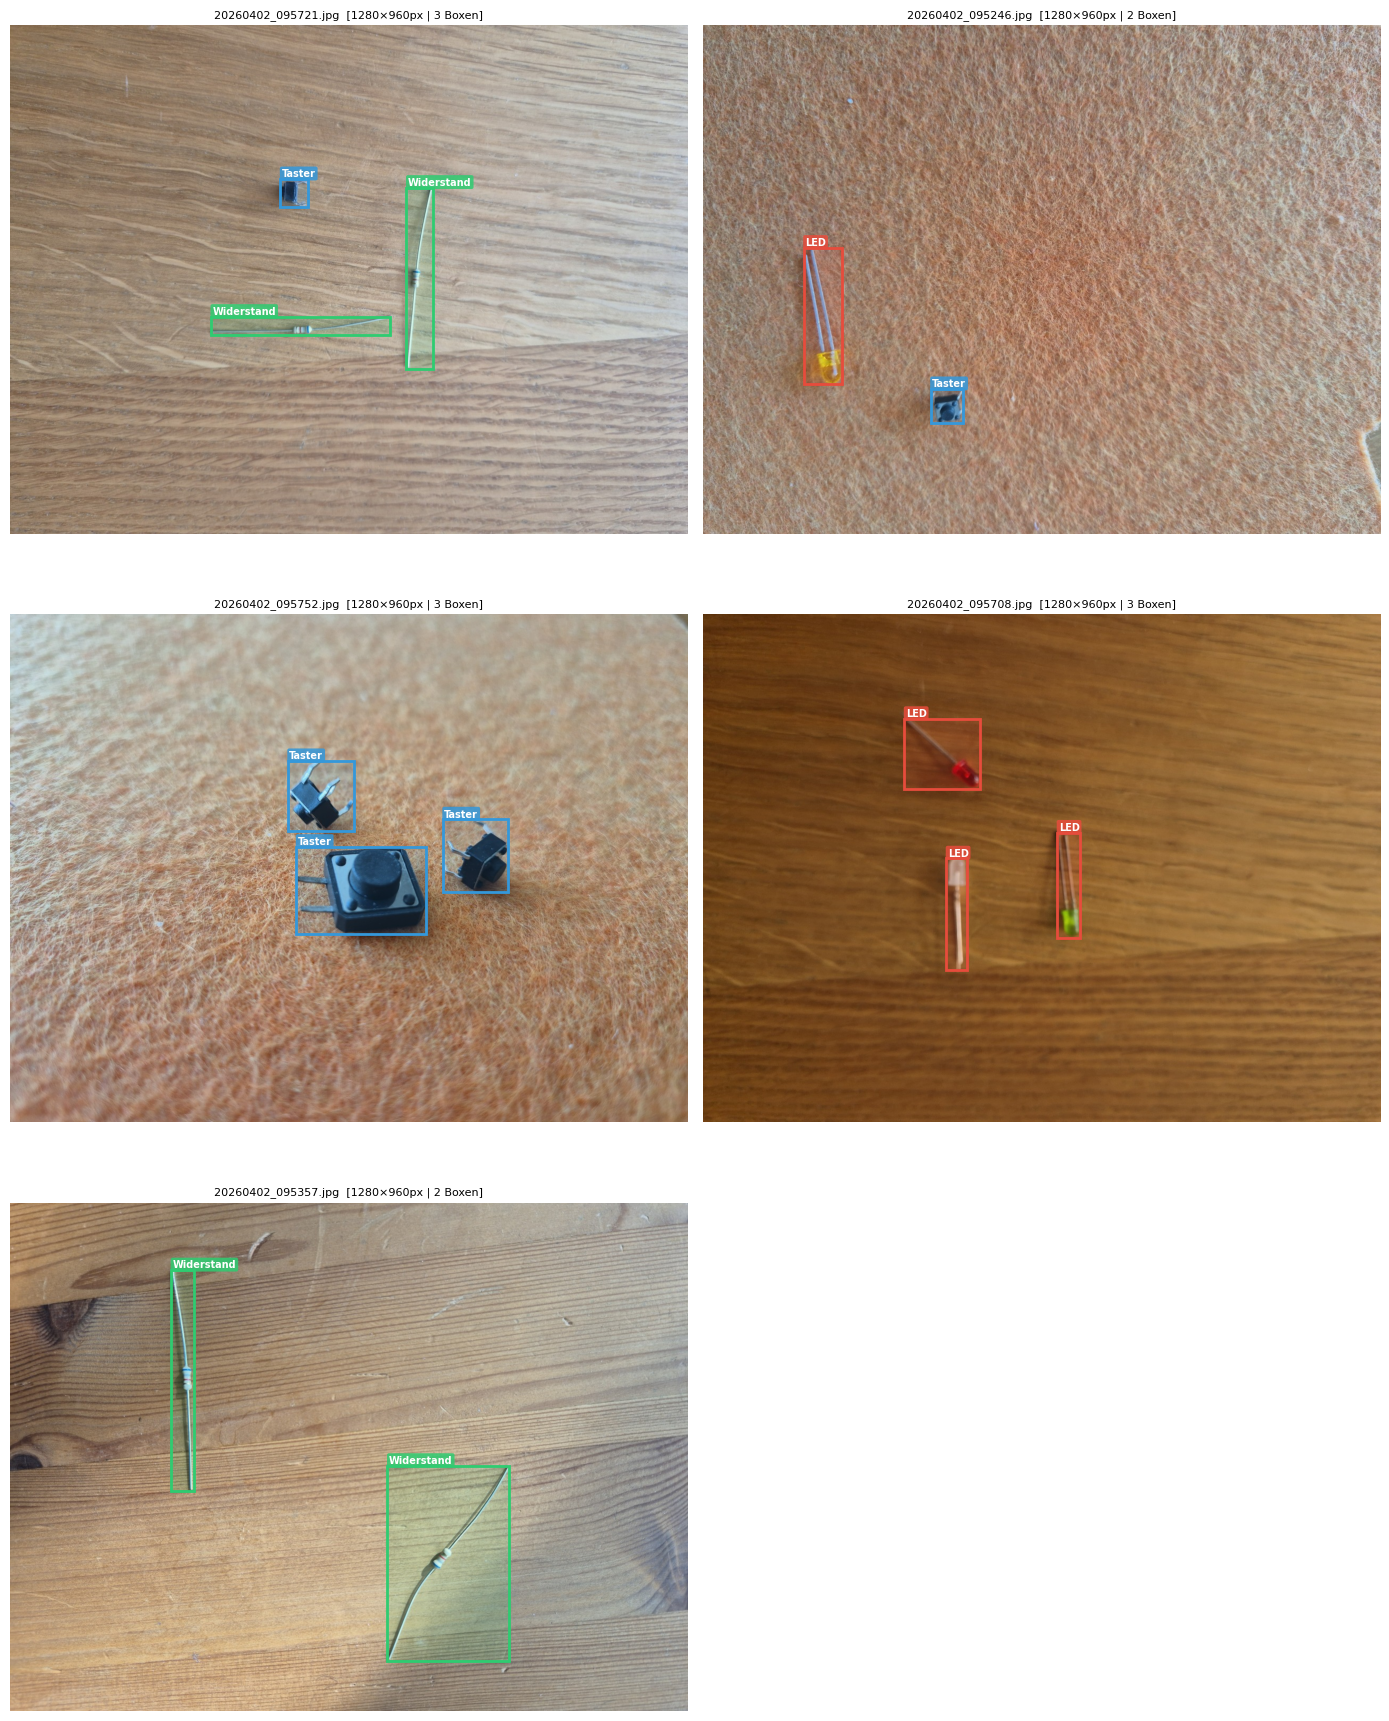


✅ 5 Bilder angezeigt  |  Klassen: ['LED', 'Taster', 'Widerstand']


In [10]:
%matplotlib inline
import pathlib, random
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.image as mpimg
import numpy as np

# ╔══════════════════════════════════════════════════════╗
# ║  Einstellungen                                        ║
# ╚══════════════════════════════════════════════════════╝
MODUS   = 'zufall'   # 'zufall' oder 'bereich'
ANZAHL  = 5          # bei 'zufall'
VON     = 1          # bei 'bereich'
BIS     = 10         # bei 'bereich'
SPALTEN = 2

FARBEN = ['#e74c3c','#3498db','#2ecc71','#f39c12',
          '#9b59b6','#1abc9c','#e67e22','#e91e63']

IMG_EXT = {'.jpg','.jpeg','.png','.bmp','.webp'}

# ── Klassennamen laden ───────────────────────────────────
# classes.txt liegt direkt in DATASET_DIR (nicht in einem Unterordner)
classes_file = DATASET_DIR / 'classes.txt'
if classes_file.exists():
    CLASS_NAMES = [l.strip() for l in
                   classes_file.read_text().splitlines() if l.strip()]
    print(f'Klassen: {CLASS_NAMES}')
else:
    CLASS_NAMES = []
    print(f'⚠️  classes.txt nicht gefunden: {classes_file.resolve()}')

# ── Bilder auswählen ─────────────────────────────────────
img_dir = DATASET_DIR / 'images'
lbl_dir = DATASET_DIR / 'labels'

alle = sorted([p for p in img_dir.iterdir()
               if p.suffix.lower() in IMG_EXT])
if not alle:
    print(f'⚠️  Keine Bilder in {img_dir.resolve()}')
else:
    if MODUS == 'zufall':
        auswahl = random.sample(alle, min(ANZAHL, len(alle)))
    else:
        auswahl = alle[VON-1:BIS]

    n_cols = min(SPALTEN, len(auswahl))
    n_rows = -(-len(auswahl) // n_cols)
    fig, axes = plt.subplots(n_rows, n_cols,
                             figsize=(7*n_cols, 6*n_rows))
    axes = np.array(axes).flatten().tolist()

    for ax, img_path in zip(axes, auswahl):
        img      = mpimg.imread(str(img_path))
        h, w     = img.shape[:2]
        lbl_path = lbl_dir / (img_path.stem + '.txt')

        ax.imshow(img)
        ax.axis('off')

        if not lbl_path.exists():
            ax.set_title(f'{img_path.name}  ⚠️ kein Label',
                         fontsize=8, color='red')
            continue

        boxen = []
        for zeile in lbl_path.read_text().strip().splitlines():
            t = zeile.strip().split()
            if len(t) == 5:
                boxen.append((int(t[0]), *map(float, t[1:])))

        ax.set_title(
            f'{img_path.name}  [{w}×{h}px | '
            f'{len(boxen)} Box{"" if len(boxen)==1 else "en"}]',
            fontsize=8)

        for cid, xc, yc, bw, bh in boxen:
            farbe = FARBEN[cid % len(FARBEN)]
            name  = CLASS_NAMES[cid] if cid < len(CLASS_NAMES) else f'cls_{cid}'
            x1    = (xc - bw/2) * w
            y1    = (yc - bh/2) * h
            ax.add_patch(patches.Rectangle(
                (x1, y1), bw*w, bh*h,
                linewidth=2, edgecolor=farbe, facecolor=farbe+'22'))
            ax.text(x1+3, y1-5, name,
                    fontsize=7, color='white', fontweight='bold',
                    bbox=dict(boxstyle='round,pad=0.2',
                              fc=farbe, alpha=0.85, ec='none'))

    for ax in axes[len(auswahl):]:
        ax.set_visible(False)

    plt.tight_layout()
    plt.show()
    plt.close()
    print(f'\n✅ {len(auswahl)} Bilder angezeigt  |  Klassen: {CLASS_NAMES}')


---
## 🏁 NB 1 abgeschlossen – Checkliste vor NB 2

- ☐ Umgebung mit `uv` eingerichtet *(Abschnitt 0)*
- ☐ Bilder aufgenommen (≥ 100 pro Klasse, variantenreich) *(Abschnitt 2)*
- ☐ Label Studio: Local Storage eingerichtet, alle Bilder annotiert, Export als YOLO *(Abschnitt 3)*
- ☐ Dateien umbenannt *(Abschnitt 4)*
- ☐ Split durchgeführt (70/20/10) *(Abschnitt 5)*
- ☐ `data.yaml` erstellt *(Abschnitt 6)*
- ☐ Abschlussbericht: kein ❌ *(Abschnitt 7)*
- ☐ Annotationskontrolle: Boxen sitzen korrekt *(Abschnitt 8)*

---
🚀 **Weiter mit NB 2:** Training in Google Colab mit **YOLO11**
